# PEMutator — Demo Notebook

**Research question:** How do binary-level PE mutations propagate through feature extraction and affect ML classifier decisions?

This notebook walks through the full experimental pipeline documented in the `try*.py` series, now packaged as the `pemutator` library.

---
### What you need
- Python ≥ 3.8 in a conda environment
- `lief`, `scikit-learn`, `numpy`, `matplotlib` installed
- The `gym-malware` repo (for the `pefeatures` extractor)
- A folder of Windows PE samples (e.g. benign `.exe` files)

Edit the two path constants in **Cell 2** to match your setup.

## 0 — Configuration

In [1]:
# ── EDIT THESE TWO PATHS ────────────────────────────────────────────────────
GYM_MALWARE_UTILS = "/media/radon/Data1/gym-malware-master/gym_malware/envs/utils"
SAMPLE_DIR        = "/media/radon/Data1/hns/mml/samples"
# ────────────────────────────────────────────────────────────────────────────

import sys, os
sys.path.insert(0, os.path.abspath(".."))  # so pemutator package is found

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

print("Environment OK")

Environment OK


## 1 — Import pemutator

In [2]:
import pemutator as pm
from pemutator.core.models import make_balanced_labels
from pemutator.viz.plots import (
    plot_size_sweep,
    plot_feature_trajectory,
    plot_mutation_sensitivity,
    plot_group_deltas,
    plot_score_heatmap,
    plot_model_comparison,
)
print(f"pemutator v{pm.__version__} imported successfully")

pemutator v0.2.0 imported successfully


## 2 — Feature Extraction

The `FeatureExtractor` wraps the gym-malware `PEFeatureExtractor` (derived from the EMBER feature set).  It produces a ~2350-dimensional vector covering:
- PE header metadata
- Section metadata
- Import/export table metadata
- Byte histogram
- 2D byte-entropy histogram

In [3]:
extractor = pm.FeatureExtractor(GYM_MALWARE_UTILS)

files = sorted(os.listdir(SAMPLE_DIR))
paths_train = [os.path.join(SAMPLE_DIR, f) for f in files[:20]]

print(f"Training set: {len(paths_train)} files")

X = extractor.extract_batch(paths_train)
print(f"Feature matrix shape: {X.shape}")
print(f"NaN rows (parse failures): {np.isnan(X).any(axis=1).sum()}")

# Quick sanity: feature[0] should be the file size (raw bytes)
print(f"\nfeature[0] stats (file-size proxy):")
print(f"  min={X[:,0].min():.0f}  max={X[:,0].max():.0f}  mean={X[:,0].mean():.0f}")

Training set: 20 files
Feature matrix shape: (20, 2350)
NaN rows (parse failures): 0

feature[0] stats (file-size proxy):
  min=49152  max=1348488  mean=210872


## 3 — Train Baseline Classifiers

We use **synthetic balanced labels** because no curated labels are available — this mirrors the approach used throughout the `try*.py` experiments.  The goal is not classification accuracy but **model sensitivity** to mutations.

In [4]:
y = make_balanced_labels(len(X))
print(f"Labels: {y.count(0)} benign, {y.count(1)} malicious (synthetic)")

models = pm.build_models()
pm.train_models(models, X, y)

for name, clf in models.items():
    train_preds = clf.predict(X)
    acc = (train_preds == y).mean()
    print(f"  {name} train accuracy: {acc:.2f}")

Labels: 10 benign, 10 malicious (synthetic)
  GBDT train accuracy: 1.00
  RF train accuracy: 1.00


## 4 — Single-Sample Probe

Pick one file and apply each of the four mutation types.  Measure:
- Absolute feature delta
- Which feature group changed most
- Whether the prediction changed

In [5]:
TARGET = os.path.join(SAMPLE_DIR, files[0])
print(f"Target: {TARGET}")

print("\n{'Mutation':<12} | {'GBDT before':>11} {'GBDT after':>10} | {'RF before':>9} {'RF after':>8} | group with max Δ")
print("-" * 90)

for mut_name, mut_fn in pm.MUTATIONS.items():
    result = pm.probe_sample(TARGET, extractor, models, mut_fn)
    sc     = result["report"]["score_changes"]
    gd     = result["report"]["group_deltas"]
    top_g  = max(gd, key=gd.get)
    print(
        f"{mut_name:<12} | "
        f"{sc['GBDT']['before']:>11.4f} {sc['GBDT']['after']:>10.4f} | "
        f"{sc['RF']['before']:>9.4f} {sc['RF']['after']:>8.4f} | "
        f"{top_g} (Δ={gd[top_g]:.1f})"
    )

Target: /media/radon/Data1/hns/mml/samples/ARP.EXE

{'Mutation':<12} | {'GBDT before':>11} {'GBDT after':>10} | {'RF before':>9} {'RF after':>8} | group with max Δ
------------------------------------------------------------------------------------------
append       |      0.0033     0.0033 |    0.2600   0.4600 | section (Δ=90114.1)
import       |      0.0033     0.0033 |    0.2600   0.2600 | section (Δ=8192.0)
header       |      0.0033     0.0033 |    0.2600   0.2600 | section (Δ=8192.0)
section      |      0.0033     0.0033 |    0.2600   0.2800 | imports (Δ=54542.4)


## 5 — Mutation Sensitivity Across Files

Replicate `try4.py` / `try5.py`: apply all four mutations to the first 10 files and measure how often each mutation triggers a prediction change in each model.

In [6]:
paths_eval = [os.path.join(SAMPLE_DIR, f) for f in files[:10]]

sens = pm.mutation_sensitivity(
    paths_eval, extractor, models,
    threshold=1e-4, verbose=True
)

print("\n=== Sensitivity Rates ===")
print(f"{'Mutation':<12} | {'GBDT':>6} | {'RF':>6}")
print("-" * 32)
for m, rates in sens["totals"].items():
    print(f"{m:<12} | {rates.get('GBDT', 0):>6.2f} | {rates.get('RF', 0):>6.2f}")

/media/radon/Data1/hns/mml/samples/ARP.EXE | append   | GBDT: 0.003→0.003(–)  RF: 0.260→0.460(✓)
/media/radon/Data1/hns/mml/samples/ARP.EXE | import   | GBDT: 0.003→0.003(–)  RF: 0.260→0.260(–)
/media/radon/Data1/hns/mml/samples/ARP.EXE | header   | GBDT: 0.003→0.003(–)  RF: 0.260→0.260(–)
/media/radon/Data1/hns/mml/samples/ARP.EXE | section  | GBDT: 0.003→0.003(–)  RF: 0.260→0.280(✓)
/media/radon/Data1/hns/mml/samples/AggregatorHost.exe | append   | GBDT: 0.003→0.003(–)  RF: 0.180→0.200(✓)
/media/radon/Data1/hns/mml/samples/AggregatorHost.exe | import   | GBDT: 0.003→0.003(–)  RF: 0.180→0.180(–)
/media/radon/Data1/hns/mml/samples/AggregatorHost.exe | header   | GBDT: 0.003→0.003(–)  RF: 0.180→0.180(–)
/media/radon/Data1/hns/mml/samples/AggregatorHost.exe | section  | GBDT: 0.003→0.003(–)  RF: 0.180→0.180(–)
/media/radon/Data1/hns/mml/samples/AppHostRegistrationVerifier.exe | append   | GBDT: 0.003→0.003(–)  RF: 0.160→0.340(✓)
/media/radon/Data1/hns/mml/samples/AppHostRegistrationVerif

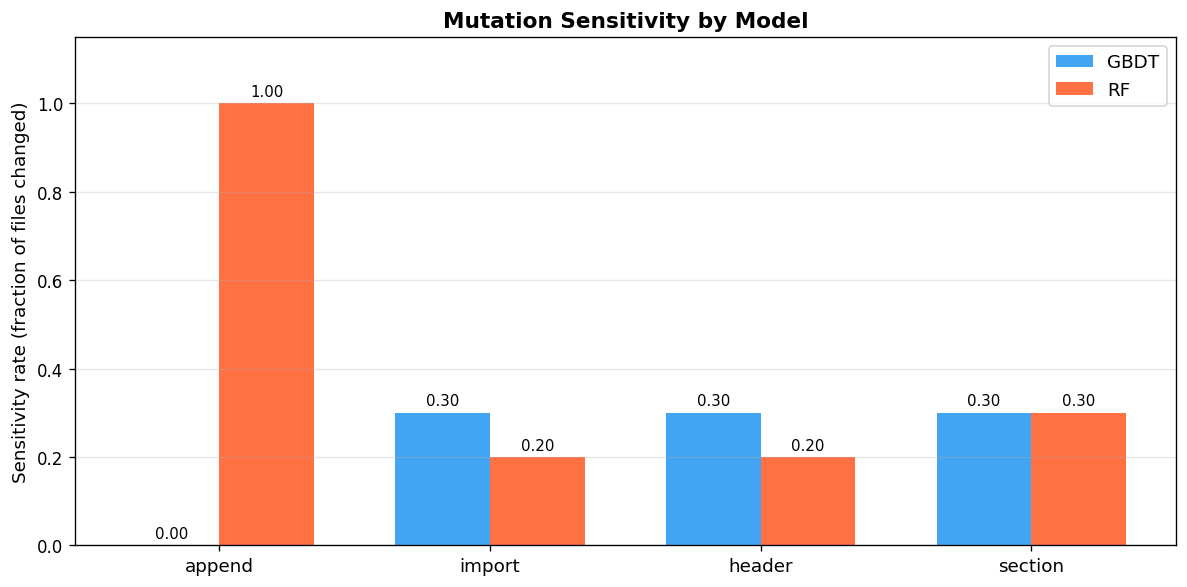

In [7]:
fig, ax = plot_mutation_sensitivity(sens)
plt.show()

## 6 — Size Sweep: The Core Experiment

Replicate `try7.py` / `try8.py`: sweep appended bytes from 0 to 20 000 in steps of 200.  This reveals the **piecewise-constant** prediction behaviour and identifies the dominant feature at the first change point.

**Expected findings:**
- `feature[0]` increases linearly (file-size proxy)
- `feature[257]` steps at ~2048-byte alignment boundaries
- The prediction stays flat for long stretches, then jumps
- The dominant feature at the jump is almost always `feat[257]`

In [8]:
SWEEP_FILE = os.path.join(SAMPLE_DIR, files[25 % len(files)])  # same index as try7.py
print(f"Sweep target: {SWEEP_FILE}")

sweep = pm.size_sweep(
    SWEEP_FILE, extractor, models,
    sizes=list(range(0, 20_000, 200)),
    track_idx=[0, 257],
    threshold=0.02,
)

print(f"\nBaseline scores: {sweep['scores_orig']}")
print("\nFirst significant change (>0.02) per model:")
for name, ch in sweep["first_change"].items():
    if ch:
        print(f"  {name}: @ {ch['size']} bytes | dominant feat[{ch['dominant_idx']}]")
    else:
        print(f"  {name}: no change detected in sweep range")

Sweep target: /media/radon/Data1/hns/mml/samples/ClipRenew.exe

Baseline scores: {'GBDT': 0.04018144353533372, 'RF': 0.38}

First significant change (>0.02) per model:
  GBDT: no change detected in sweep range
  RF: no change detected in sweep range


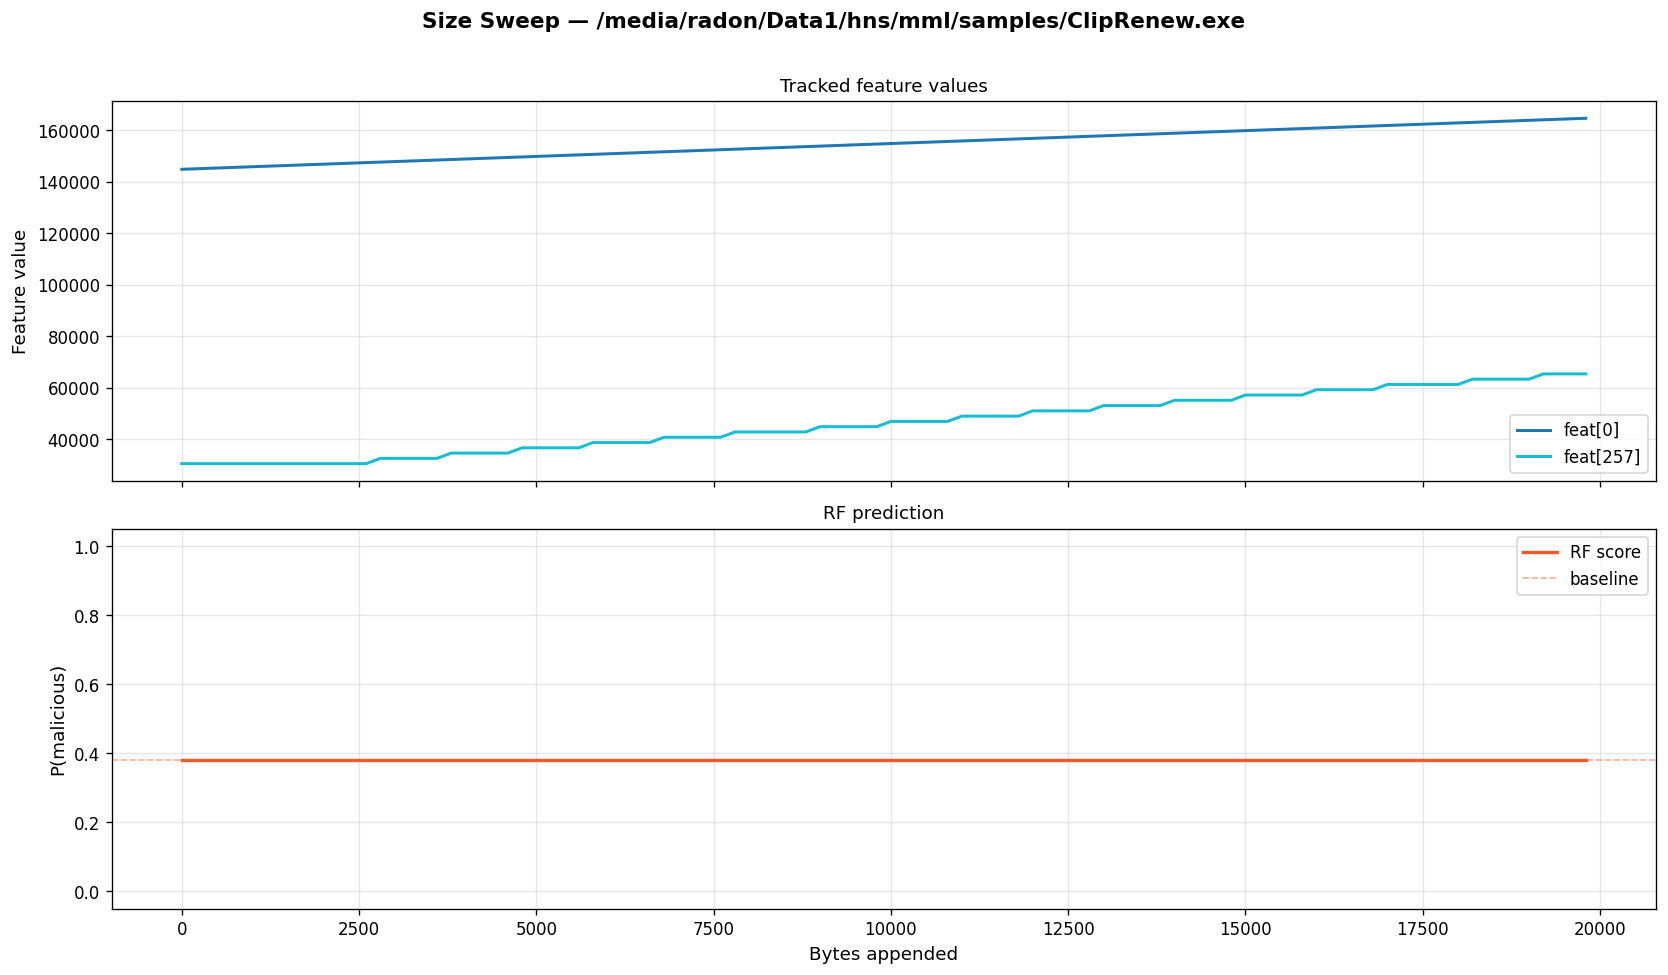

In [9]:
fig, axes = plot_size_sweep(sweep, model_name="RF", track_idx=[0, 257])
plt.show()

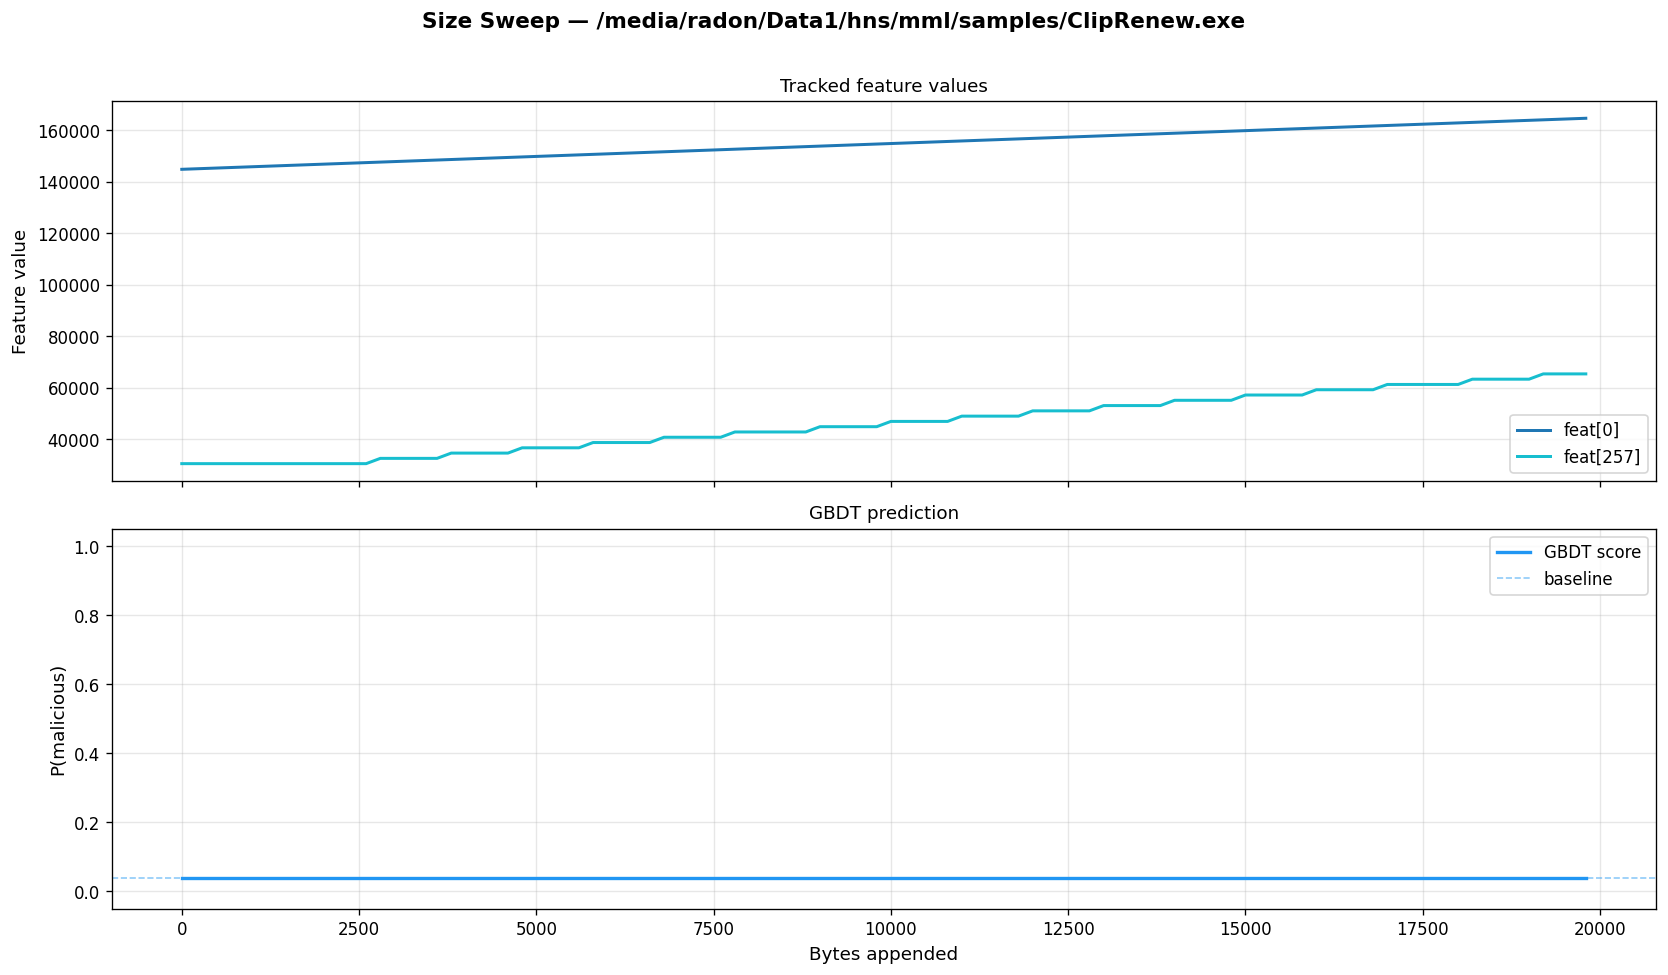

In [10]:
fig, axes = plot_size_sweep(sweep, model_name="GBDT", track_idx=[0, 257])
plt.show()

## 7 — Feature Trajectory: Linear vs Discrete

Plot several important feature indices across the sweep to confirm the qualitative difference between smoothly-changing and step-changing features.

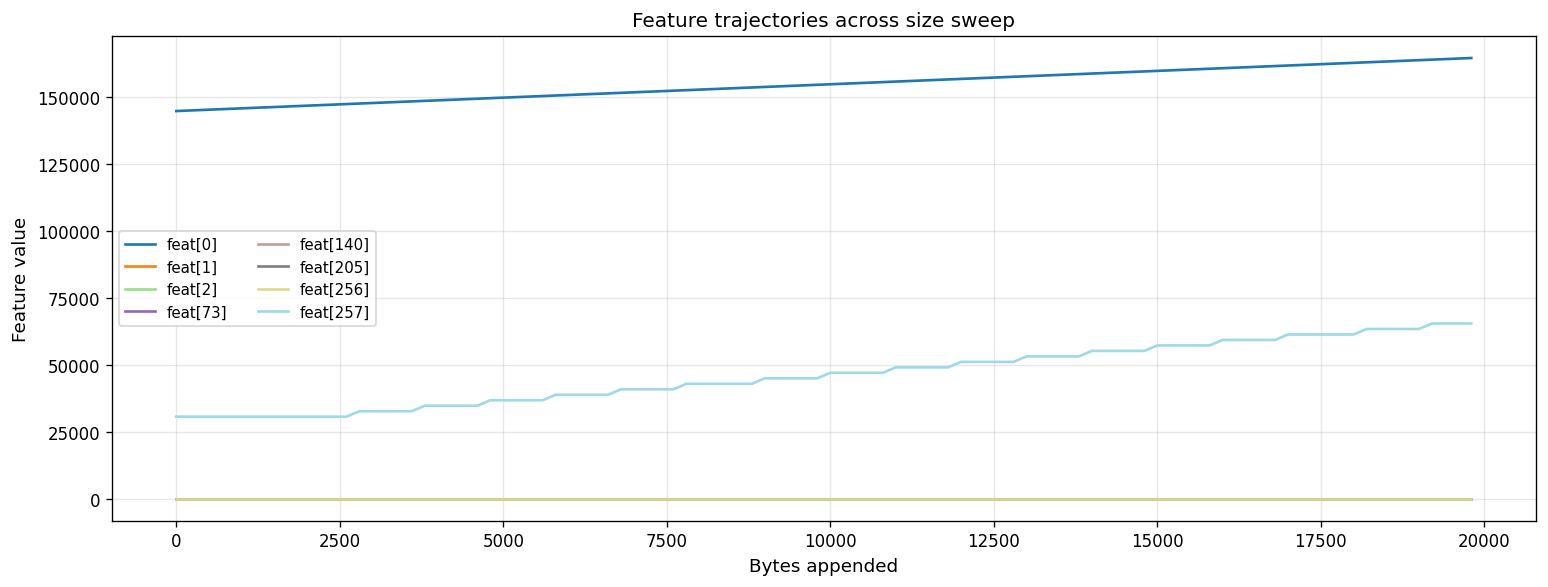

In [11]:
from pemutator.analysis.delta import IMPORTANT_IDX

# Rebuild sweep with all important indices tracked
sweep_full = pm.size_sweep(
    SWEEP_FILE, extractor, models,
    sizes=list(range(0, 20_000, 200)),
    track_idx=IMPORTANT_IDX,
    threshold=0.02,
)

fig, ax = plot_feature_trajectory(sweep_full, indices=IMPORTANT_IDX)
plt.show()

## 8 — Group-Level Feature Delta

Stacked area chart showing which feature group accumulates the most delta as bytes are appended.  Header and section groups typically dominate.

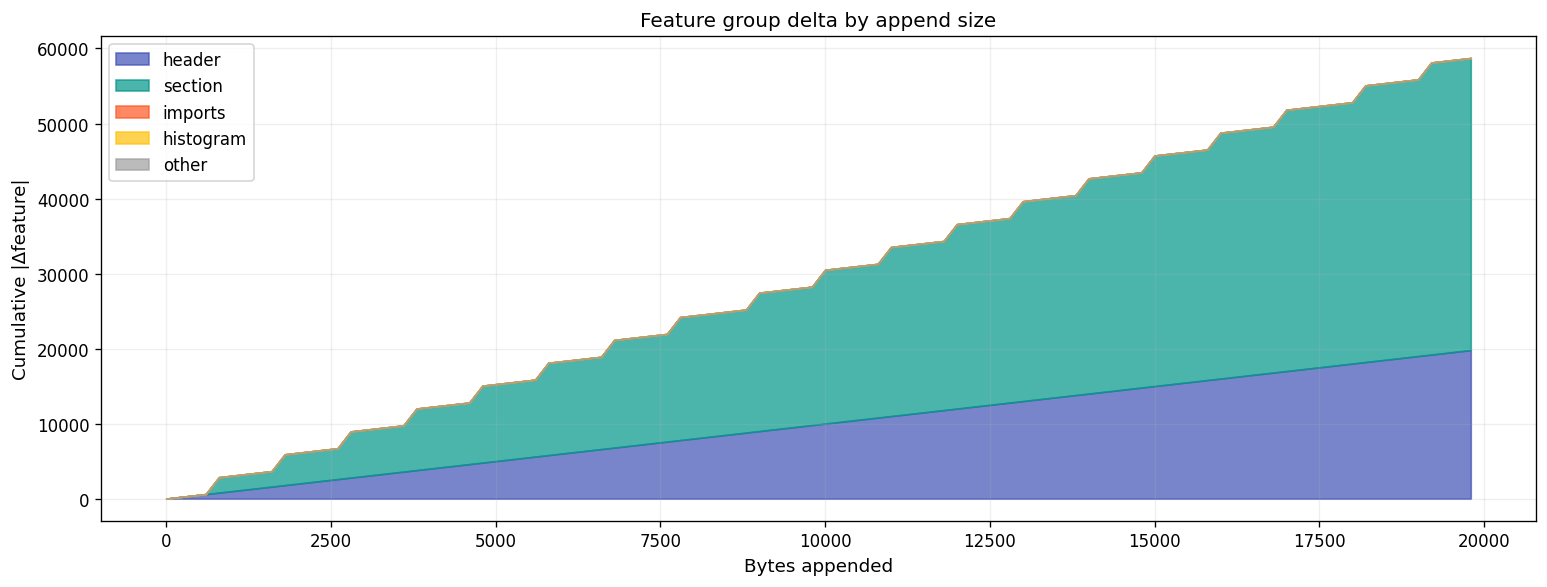

In [12]:
fig, ax = plot_group_deltas(sweep)
plt.show()

## 9 — Score Heatmap: (File × Mutation)

Visualise the post-mutation prediction score for every (file, mutation) combination in the sensitivity experiment.

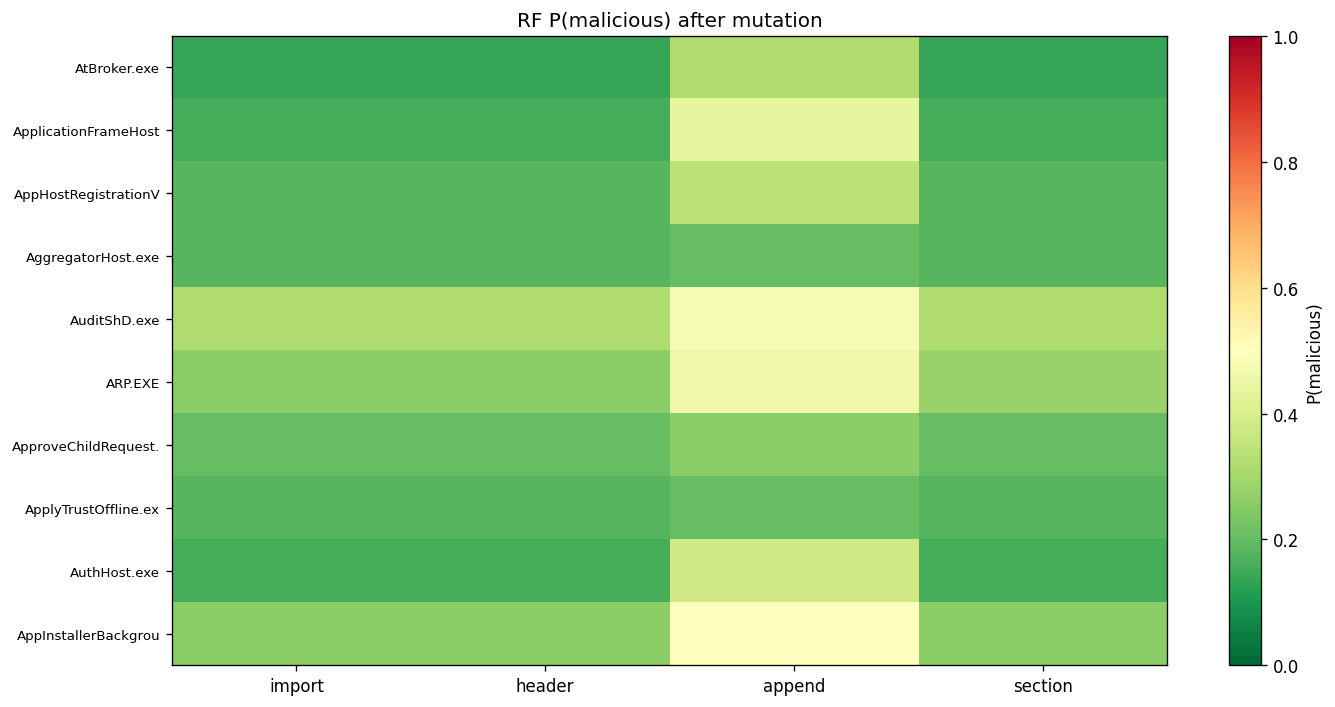

In [13]:
fig, ax = plot_score_heatmap(sens, model_name="RF")
plt.show()

## 10 — GBDT vs RF: Model Comparison Scatter

Points above the diagonal: RF predicts higher maliciousness than GBDT.  The divergence reveals **architecture-level sensitivity differences** for the same input.

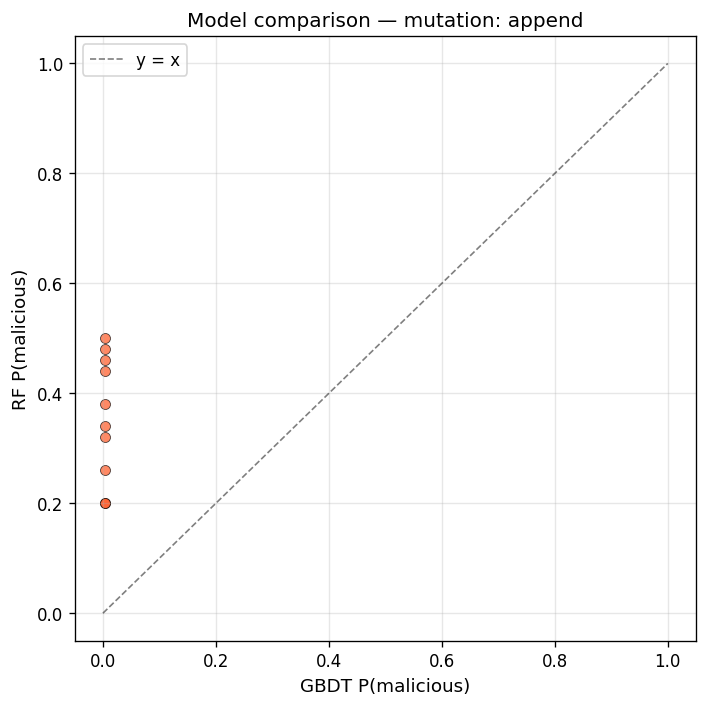

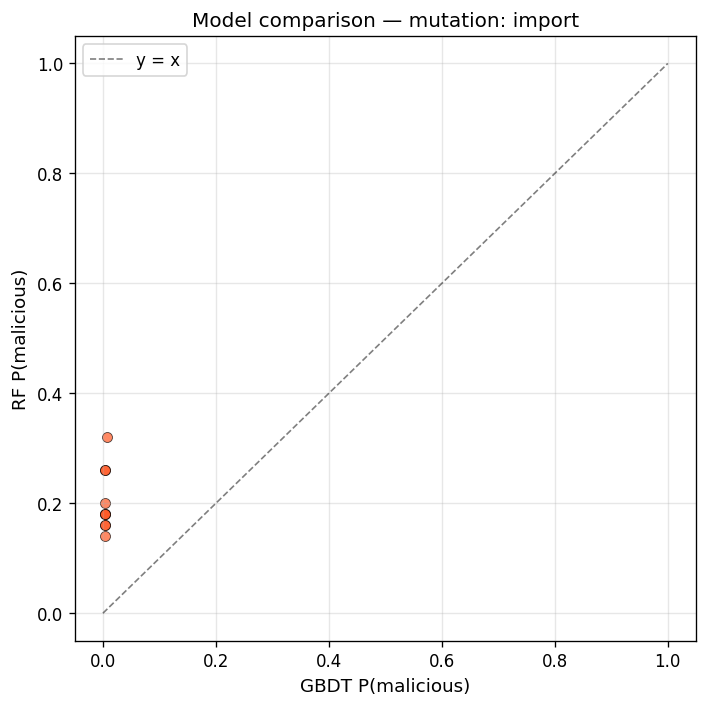

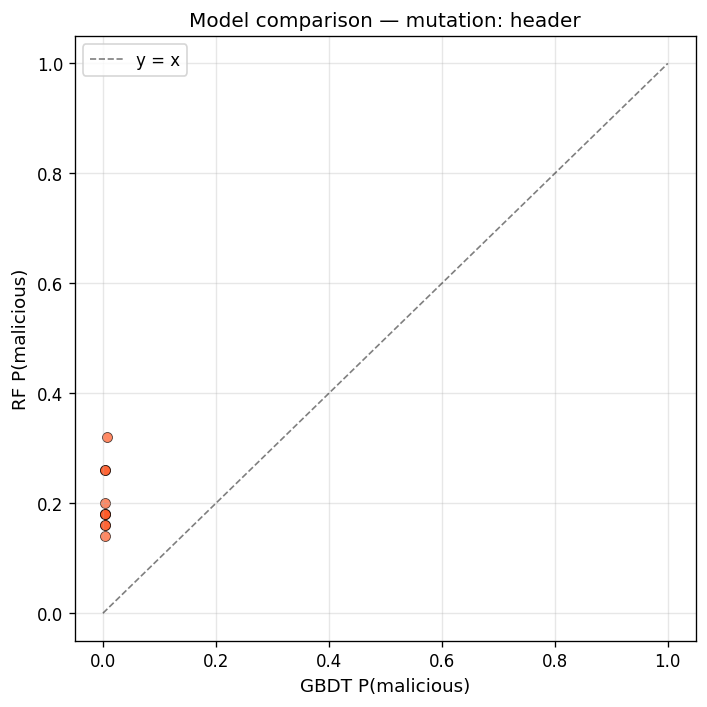

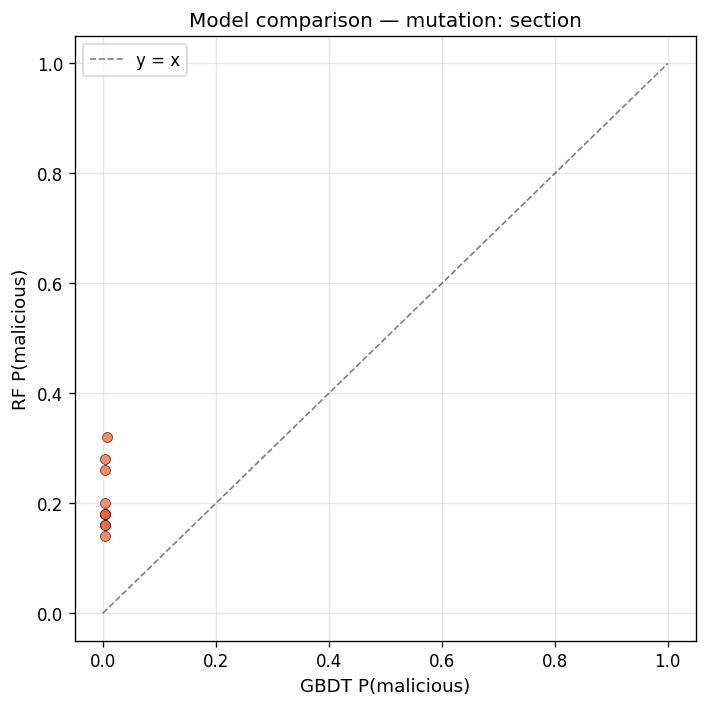

In [14]:
for mut in pm.MUTATIONS:
    try:
        fig, ax = plot_model_comparison(sens, mut_name=mut)
        plt.show()
    except ValueError as e:
        print(f"  Skipping {mut}: {e}")

## 11 — Perturbation Threshold Survey

For each file in the eval set, find the **minimum append size** required to trigger a prediction change in the RF model.

In [15]:
thresholds = []

for path in paths_eval:
    sw = pm.size_sweep(
        path, extractor, models,
        sizes=list(range(0, 20_000, 500)),
        track_idx=[0, 257],
        threshold=0.02,
    )
    ch = sw["first_change"].get("RF")
    fname = os.path.basename(path)
    if ch:
        print(f"{fname:<40} first change @ {ch['size']:>6} bytes  (feat[{ch['dominant_idx']}])")
        thresholds.append(ch["size"])
    else:
        print(f"{fname:<40} no change in sweep range")

if thresholds:
    print(f"\nThreshold stats: min={min(thresholds)}  max={max(thresholds)}  mean={np.mean(thresholds):.0f}")

ARP.EXE                                  first change @      0 bytes  (feat[257])
AggregatorHost.exe                       no change in sweep range
AppHostRegistrationVerifier.exe          first change @   7000 bytes  (feat[257])
AppInstallerBackgroundUpdate.exe         first change @    500 bytes  (feat[0])
ApplicationFrameHost.exe                 first change @   1000 bytes  (feat[0])
ApplyTrustOffline.exe                    first change @   4500 bytes  (feat[257])
ApproveChildRequest.exe                  first change @      0 bytes  (feat[257])
AtBroker.exe                             first change @  16000 bytes  (feat[257])
AuditShD.exe                             first change @   2000 bytes  (feat[257])
AuthHost.exe                             first change @   1500 bytes  (feat[0])

Threshold stats: min=0  max=16000  mean=3611


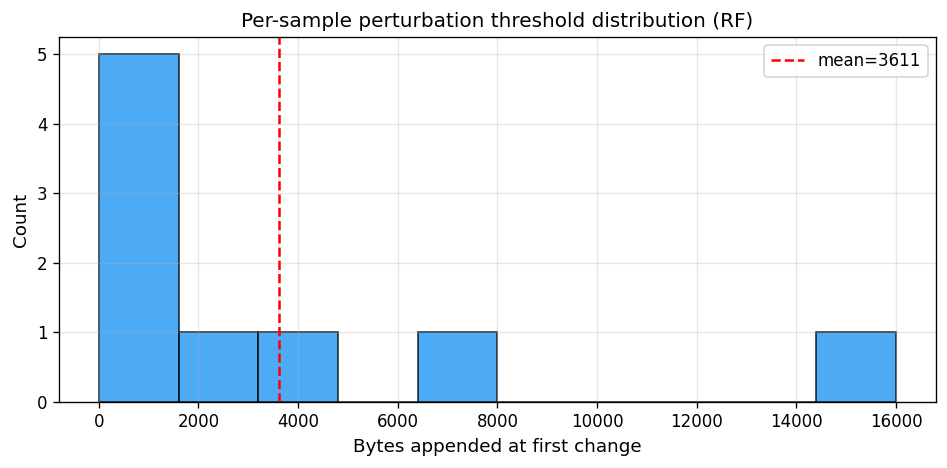

In [16]:
if thresholds:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(thresholds, bins=10, color="#2196F3", edgecolor="k", alpha=0.8)
    ax.axvline(np.mean(thresholds), color="red", linestyle="--", label=f"mean={np.mean(thresholds):.0f}")
    ax.set_xlabel("Bytes appended at first change", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.set_title("Per-sample perturbation threshold distribution (RF)", fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 12 — Summary of Key Findings

| Finding | Observed in | Explanation |
|---------|-------------|-------------|
| **Piecewise-constant predictions** | Size sweep (§6) | Decision trees partition feature space into discrete regions; crossing a boundary flips the vote |
| **Decoupling of feature drift and prediction** | §6, §7 | `feat[0]` grows linearly but predictions stay flat; only `feat[257]` crossing a threshold triggers a change |
| **Discrete alignment steps** | §7 | `feat[257]` (section/file size alignment) steps at ~2048-byte boundaries — a PE structural property |
| **Sample-dependent thresholds** | §11 | Minimum perturbation to change prediction varies widely per file — robustness is not a global property |
| **Mutation type matters** | §5 | Append is most effective; import/section mutations often have little effect |
| **Architecture sensitivity differs** | §10 | GBDT and RF show different sensitivity profiles on identical feature vectors |
| **Sparse effective feature set** | §8 | Despite ~2350 features, prediction changes are driven by a handful of indices |

---
*Built on gym-malware + EMBER feature pipeline + LIEF.  Models trained on synthetic labels for experimental purposes only.*

---
# Part II — Evasion & Feature Attribution

The sections below move from *observation* to *action*: instead of just measuring how mutations affect features, we now run structured evasion attempts and ask which features the model actually relies on.


## 13 — Single-File Evasion (Greedy)

`GreedyEvasion` evaluates all four mutations at each step and commits to whichever drops the score the most.  This is a deterministic hill-climbing baseline equivalent to the steepest-descent policy — the opposite end of the spectrum from the full RL agent in Anderson et al.

In [17]:
from pemutator.analysis.evasion import GreedyEvasion, RandomEvasion
from pemutator.viz.evasion_plots import (
    plot_evasion_trajectory,
    plot_score_waterfall,
    plot_campaign_summary,
    plot_fingerprint_bar,
    plot_attack_surface,
    plot_rank_comparison,
)

TARGET_FILE = os.path.join(SAMPLE_DIR, files[0])
print(f"Target: {TARGET_FILE}")

# Run greedy evasion against Random Forest
greedy_rf = GreedyEvasion(
    extractor, models["RF"], pm.MUTATIONS,
    target=0.4,      # try to get score below 0.4
    max_steps=10,
)
result_greedy = greedy_rf.run(TARGET_FILE)

print(f"\nEvaded: {result_greedy.evaded}")
print(f"Steps:  {result_greedy.steps_taken}")
print(f"Score:  {result_greedy.initial_score:.4f} → {result_greedy.final_score:.4f}")
print(f"Score drop: {result_greedy.score_drop:.4f}")
print(f"Effective mutations: {result_greedy.effective_mutations}")

Target: /media/radon/Data1/hns/mml/samples/ARP.EXE

Evaded: True
Steps:  0
Score:  0.2600 → 0.2600
Score drop: 0.0000
Effective mutations: []


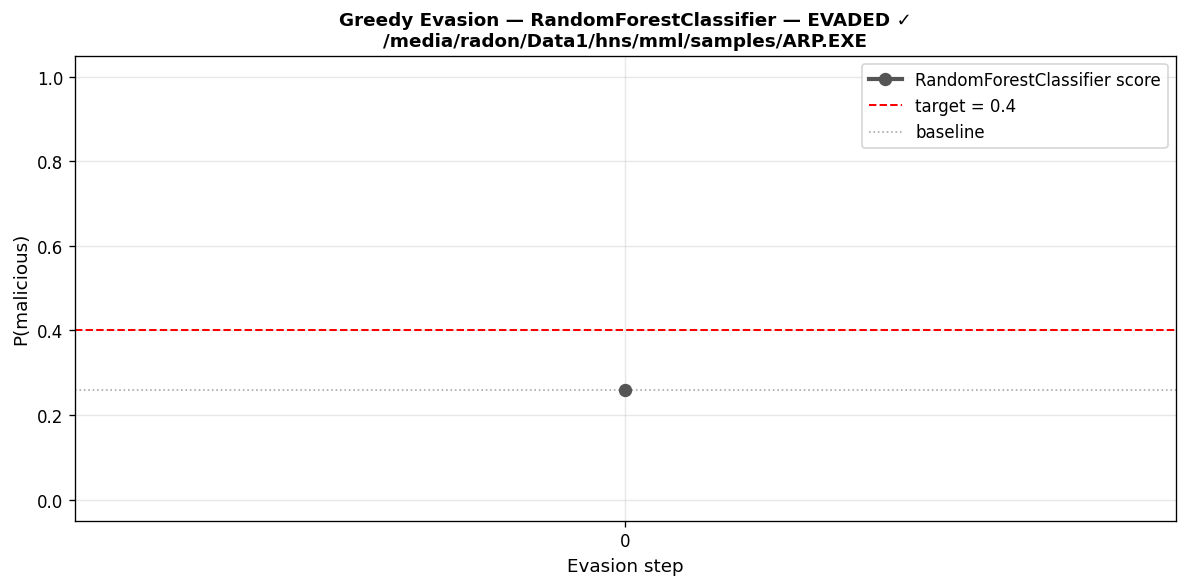

In [18]:
fig, ax = plot_evasion_trajectory(result_greedy)
plt.show()

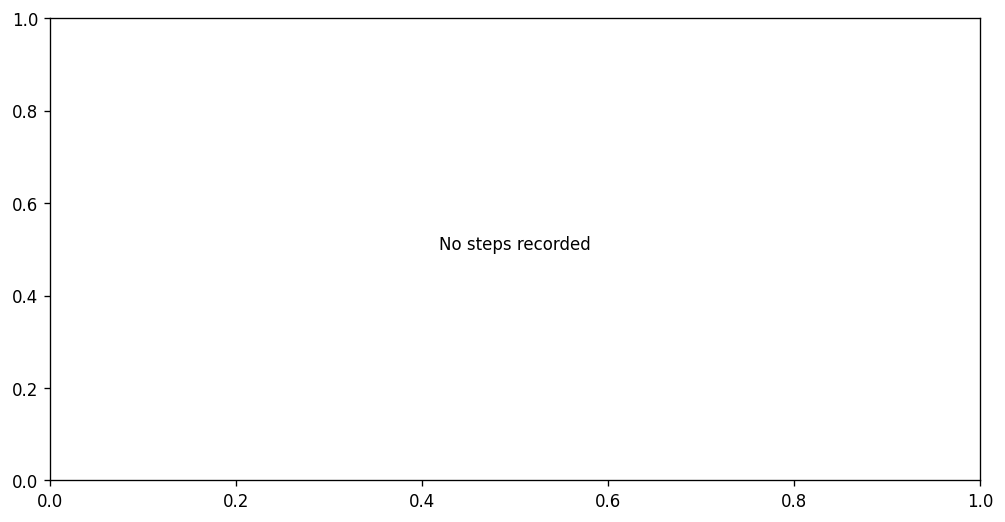

In [19]:
fig, ax = plot_score_waterfall(result_greedy)
plt.show()

## 14 — Greedy vs Random: Head-to-Head

Compare the greedy and random strategies on the same file and model.
As in Table 2 of Anderson et al., we expect greedy to find the change point in fewer steps,
even if the final evasion rates are similar.

Greedy:  0.26 → 0.26  | steps=0 | evaded=True
Random:  0.26 → 0.26  | steps=0 | evaded=True


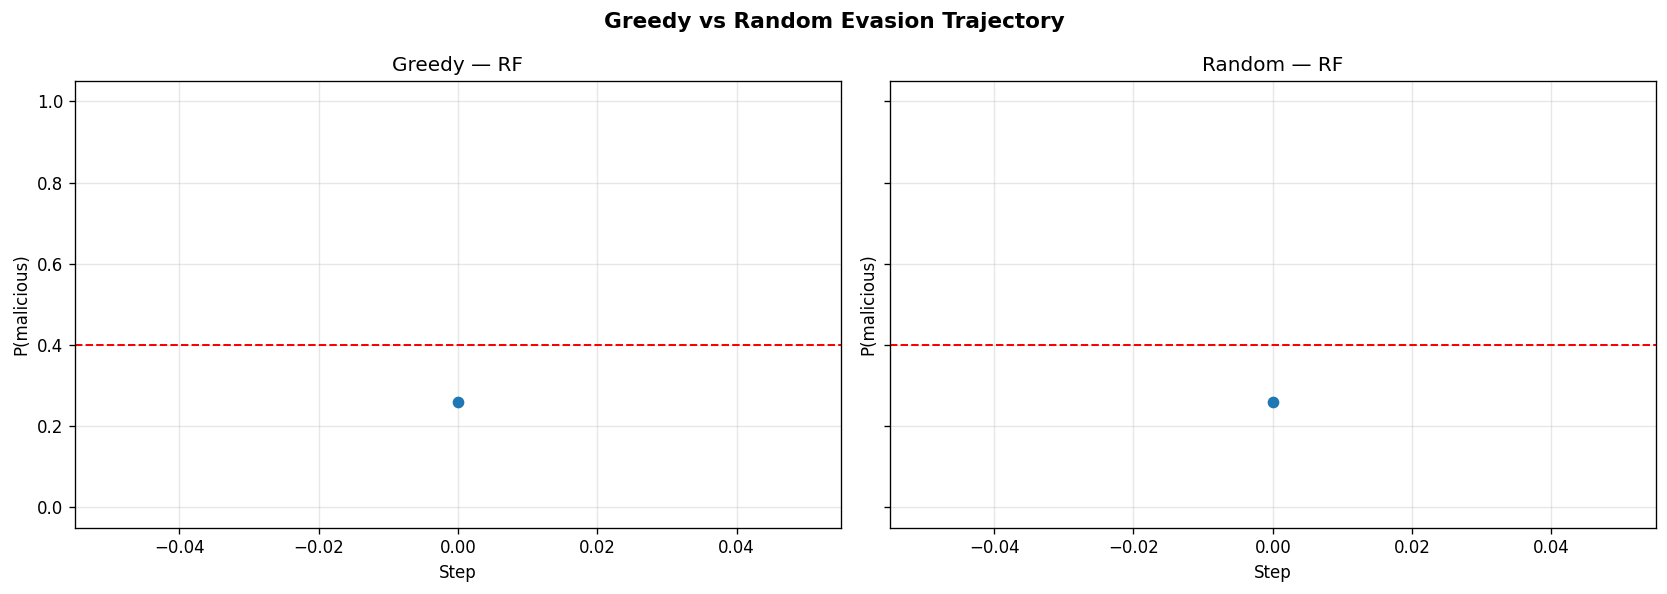

In [20]:
random_rf = RandomEvasion(
    extractor, models["RF"], pm.MUTATIONS,
    target=0.4, max_steps=10,
)
result_random = random_rf.run(TARGET_FILE)

print("Greedy: ", result_greedy.initial_score, "→", result_greedy.final_score,
      f" | steps={result_greedy.steps_taken} | evaded={result_greedy.evaded}")
print("Random: ", result_random.initial_score, "→", result_random.final_score,
      f" | steps={result_random.steps_taken} | evaded={result_random.evaded}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, res, title in zip(axes,
                           [result_greedy, result_random],
                           ["Greedy", "Random"]):
    ax.plot(res.trajectory, marker="o", linewidth=2)
    ax.axhline(res.target, color="red", linestyle="--", linewidth=1.2)
    ax.set_title(f"{title} — RF", fontsize=12)
    ax.set_xlabel("Step"); ax.set_ylabel("P(malicious)")
    ax.set_ylim(-0.05, 1.05); ax.grid(True, alpha=0.3)
plt.suptitle("Greedy vs Random Evasion Trajectory", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 15 — Evasion Campaign Across Files

Run the greedy evader across all eval-set files for both models and compute aggregate statistics.

In [21]:
from pemutator.analysis.evasion import run_evasion_campaign, evasion_summary

campaign = run_evasion_campaign(
    paths_eval, extractor, models, pm.MUTATIONS,
    strategy="greedy", target=0.4, max_steps=10, verbose=True,
)

summary = evasion_summary(campaign)

print("\n=== Campaign Summary ===")
for name, s in summary.items():
    print(f"  {name}: evasion_rate={s['evasion_rate']:.2f}  "
          f"avg_steps={s['avg_steps']:.1f}  "
          f"avg_drop={s['avg_score_drop']:.3f}")
    print(f"    effective mutations: {s['mutation_counts']}")


── GREEDY evasion against GBDT ──
  EVADED ✓  ARP.EXE                         0.003 → 0.003  (0 steps)
  EVADED ✓  AggregatorHost.exe              0.003 → 0.003  (0 steps)
  EVADED ✓  AppHostRegistrationVerifier.exe  0.003 → 0.003  (0 steps)
  EVADED ✓  AppInstallerBackgroundUpdate.exe  0.003 → 0.003  (0 steps)
  EVADED ✓  ApplicationFrameHost.exe        0.003 → 0.003  (0 steps)
  EVADED ✓  ApplyTrustOffline.exe           0.003 → 0.003  (0 steps)
  EVADED ✓  ApproveChildRequest.exe         0.003 → 0.003  (0 steps)
  EVADED ✓  AtBroker.exe                    0.003 → 0.003  (0 steps)
  EVADED ✓  AuditShD.exe                    0.003 → 0.003  (0 steps)
  EVADED ✓  AuthHost.exe                    0.003 → 0.003  (0 steps)

── GREEDY evasion against RF ──
  EVADED ✓  ARP.EXE                         0.260 → 0.260  (0 steps)
  EVADED ✓  AggregatorHost.exe              0.180 → 0.180  (0 steps)
  EVADED ✓  AppHostRegistrationVerifier.exe  0.160 → 0.160  (0 steps)
  EVADED ✓  AppInstallerBackgro

/media/radon/Data1/hns/mml/pemutator/viz/evasion_plots.py:145: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax2.set_ylim(0, max(drops) * 1.3 if drops else 1)


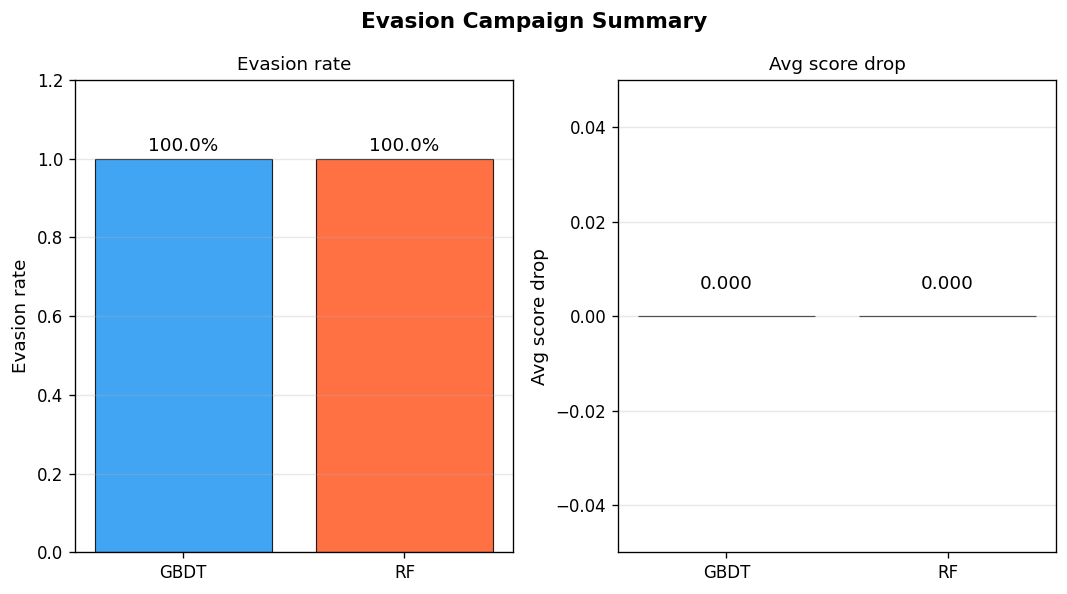

In [22]:
fig, axes = plot_campaign_summary(summary)
plt.show()

## 16 — Feature Fingerprinting

Extract the models' built-in feature importances and compare them against the *empirical* importances derived from the size sweep (features that changed when predictions flipped).

This answers the core question: **do the features the model thinks are important overlap with the features our mutations can actually reach?**  The overlap is the "attack surface".

In [23]:
from pemutator.analysis.fingerprint import (
    ModelFingerprint, empirical_importance, attack_surface, compare_fingerprints
)

fp_gbdt = ModelFingerprint(models["GBDT"], model_name="GBDT")
fp_rf   = ModelFingerprint(models["RF"],   model_name="RF")

print(fp_gbdt)
print(fp_rf)

print("\n── GBDT group importance ──")
for g, v in fp_gbdt.group_importance().items():
    print(f"  {g:<12}: {v:.3f}")

print("\n── RF group importance ──")
for g, v in fp_rf.group_importance().items():
    print(f"  {g:<12}: {v:.3f}")

print("\n── Experiment-identified indices in GBDT ──")
for idx, info in fp_gbdt.report_indices().items():
    print(f"  feat[{idx:>3}]: importance={info['importance']:.5f}  rank={info['rank']}  top-{info['percentile']:.1f}%")

ModelFingerprint(GBDT, n_features=2350, top3=[569, 601, 32])
ModelFingerprint(RF, n_features=2350, top3=[138, 3, 584])

── GBDT group importance ──
  header      : 0.145
  section     : 0.081
  imports     : 0.647
  histogram   : 0.127
  other       : 0.000

── RF group importance ──
  header      : 0.186
  section     : 0.475
  imports     : 0.239
  histogram   : 0.081
  other       : 0.018

── Experiment-identified indices in GBDT ──
  feat[  0]: importance=0.00000  rank=2350  top-0.0%
  feat[  1]: importance=0.00000  rank=797  top-66.1%
  feat[  2]: importance=0.00000  rank=796  top-66.1%
  feat[ 73]: importance=0.00000  rank=782  top-66.7%
  feat[140]: importance=0.00000  rank=837  top-64.4%
  feat[205]: importance=0.00000  rank=635  top-73.0%
  feat[256]: importance=0.00000  rank=731  top-68.9%
  feat[257]: importance=0.00000  rank=730  top-68.9%


In [24]:
# Derive empirical importance from the sweep we ran earlier
emp_imp_rf = empirical_importance(
    sweep["records"], sweep["scores_orig"],
    model_name="RF", threshold=0.02,
    n_features=extractor.n_features or 2350,
)

print(f"Empirical importance: {(emp_imp_rf > 0).sum()} non-zero features out of {len(emp_imp_rf)}")
top_emp = np.argsort(emp_imp_rf)[::-1][:10]
print(f"Top-10 empirically important indices: {top_emp.tolist()}")

Empirical importance: 0 non-zero features out of 2350
Top-10 empirically important indices: [2349, 771, 787, 786, 785, 784, 783, 782, 781, 780]


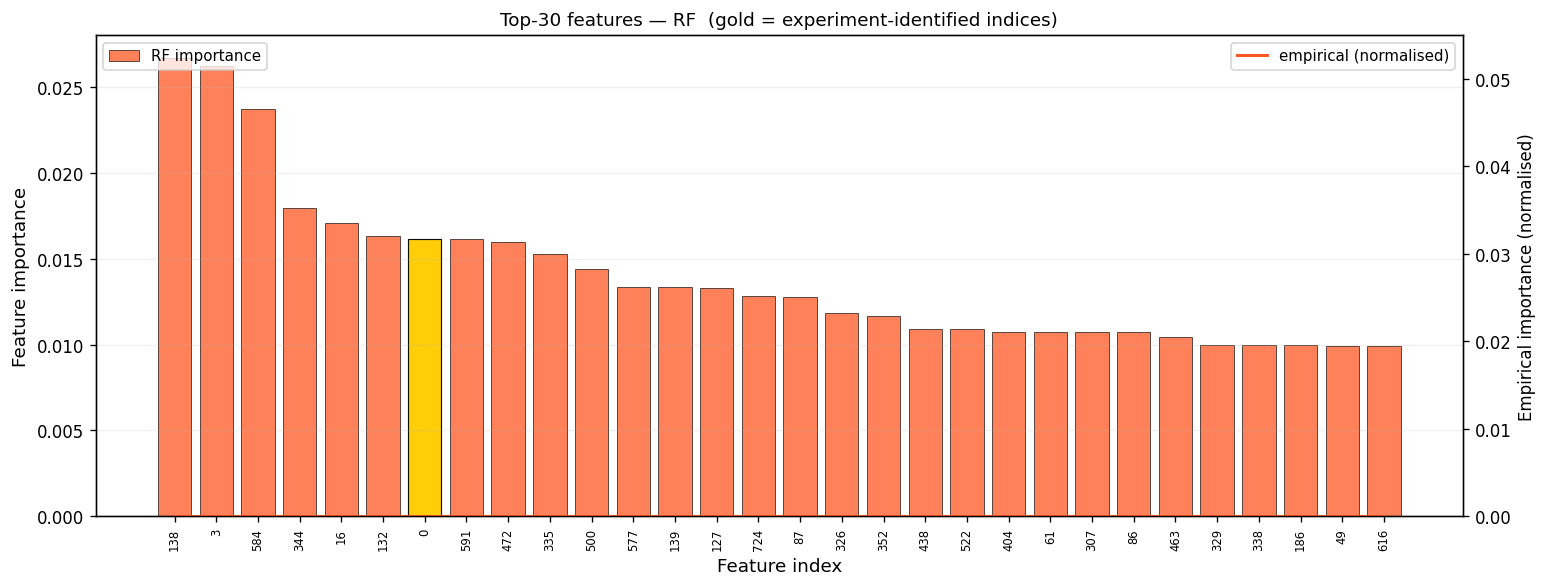

In [25]:
fig, ax = plot_fingerprint_bar(fp_rf, empirical_imp=emp_imp_rf, top_k=30)
plt.show()

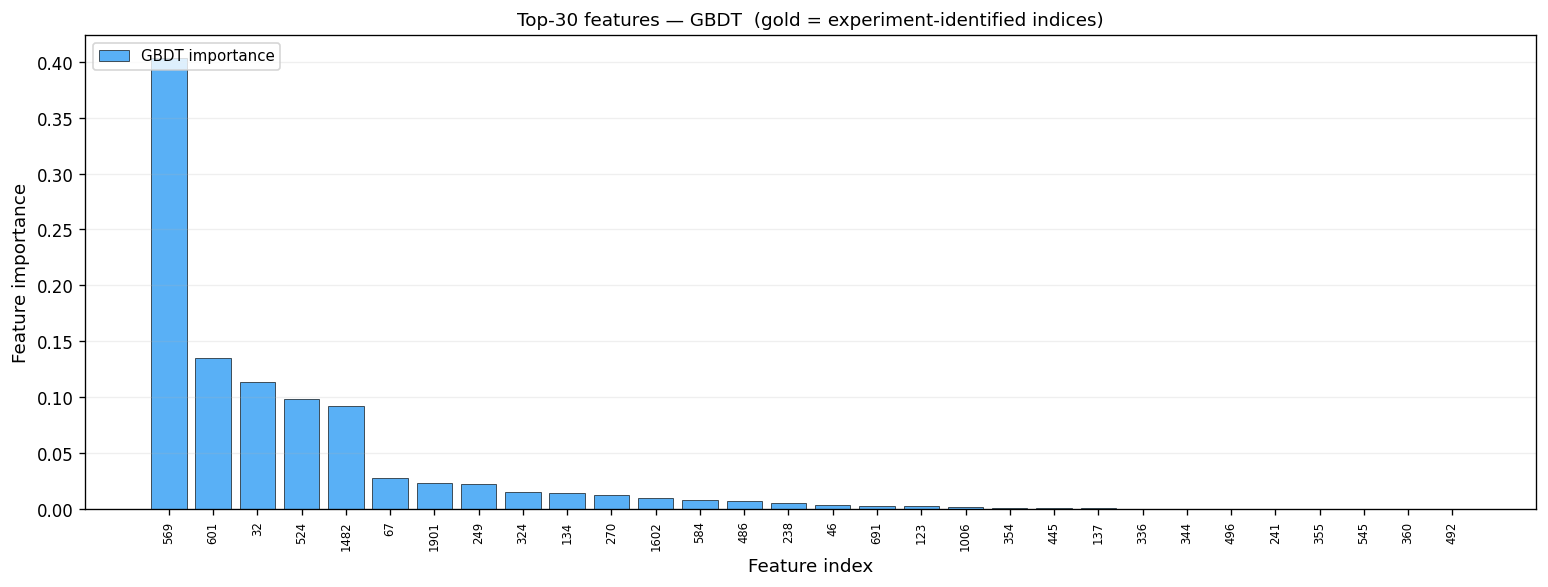

In [26]:
fig, ax = plot_fingerprint_bar(fp_gbdt, top_k=30)
plt.show()

### Attack Surface

In [27]:
surface_rf = attack_surface(fp_rf, emp_imp_rf, top_k=50)

print(f"Model top-50 features:      {len(surface_rf['model_top'])}")
print(f"Mutation-reachable features: {len(surface_rf['reachable'])}")
print(f"Overlap (attack surface):    {surface_rf['overlap_size']}")
print(f"\nOverlap indices: {surface_rf['overlap'].tolist()}")

if surface_rf['overlap_scores']:
    print("\n── Overlap feature details ──")
    for idx, info in sorted(surface_rf['overlap_scores'].items(),
                             key=lambda x: -x[1]['model_importance']):
        print(f"  feat[{idx:>4}]: model_imp={info['model_importance']:.5f}  "
              f"empirical={info['empirical_importance']:.5f}")

Model top-50 features:      50
Mutation-reachable features: 0
Overlap (attack surface):    0

Overlap indices: []


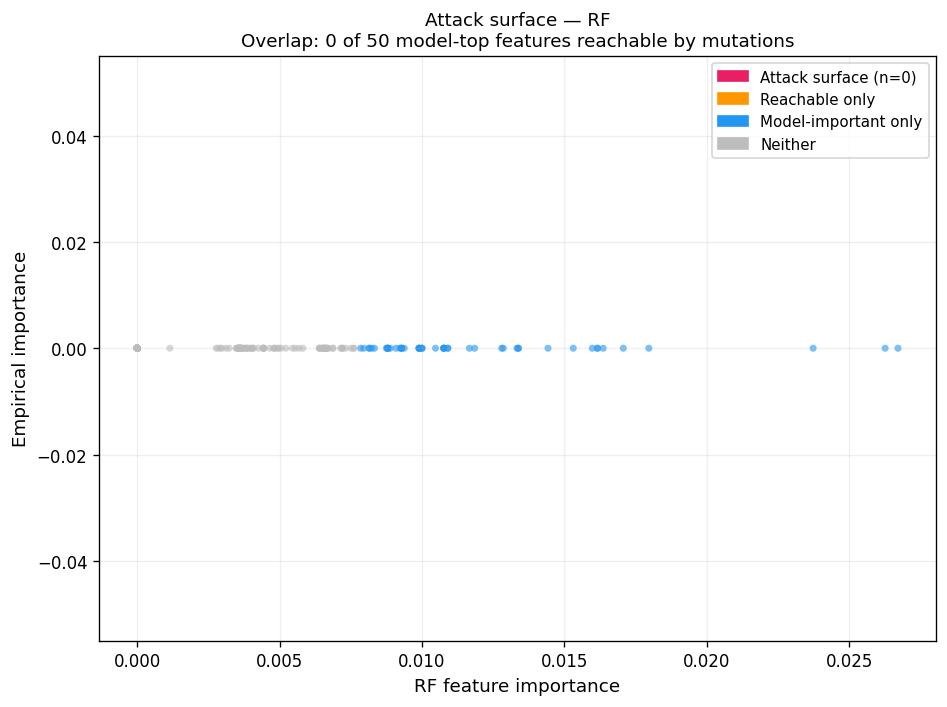

In [28]:
fig, ax = plot_attack_surface(surface_rf, fp_rf, emp_imp_rf)
plt.show()

## 17 — Cross-Model Feature Agreement

Compare GBDT and RF feature importance rankings.  Features near the diagonal of the rank-comparison scatter are important to *both* models — these are the most robust attack targets.
Features far off the diagonal are architecture-specific blind spots.

In [29]:
comparison = compare_fingerprints({"GBDT": fp_gbdt, "RF": fp_rf}, top_k=50)

print(f"Union of top-50 features:        {len(comparison['union'])}")
print(f"Intersection (both top-50):      {len(comparison['intersection'])}")

if len(comparison['intersection']) > 0:
    print(f"\nShared important features: {comparison['intersection'].tolist()}")
    print("\n── Rank comparison for shared features ──")
    print(f"{'Index':>6}  {'GBDT rank':>10}  {'RF rank':>8}")
    for idx in comparison['intersection']:
        rm = comparison['rank_matrix'][int(idx)]
        print(f"  {idx:>4}      {rm['GBDT']:>6}        {rm['RF']:>6}")

Union of top-50 features:        97
Intersection (both top-50):      3

Shared important features: [46, 344, 584]

── Rank comparison for shared features ──
 Index   GBDT rank   RF rank
    46          16            45
   344          24             4
   584          13             3


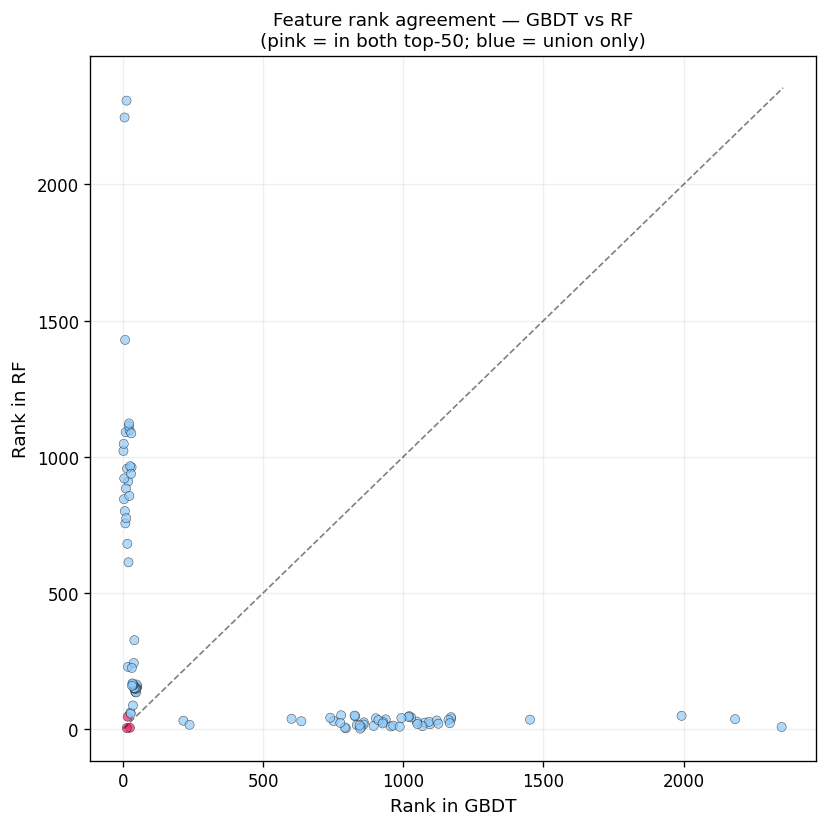

In [30]:
fig, ax = plot_rank_comparison(comparison, fp_gbdt, fp_rf, top_k=50)
plt.show()

## 18 — Consolidated Findings Table

Pull together all quantitative results from the notebook into one summary.

In [31]:
print("=" * 72)
print(" PEMUTATOR — CONSOLIDATED RESULTS")
print("=" * 72)

print("\n[1] Mutation Sensitivity (fraction of files with prediction change)")
print(f"  {'Mutation':<12}  {'GBDT':>6}  {'RF':>6}")
for m, rates in sens['totals'].items():
    print(f"  {m:<12}  {rates.get('GBDT',0):>6.2f}  {rates.get('RF',0):>6.2f}")

print("\n[2] Size Sweep — first prediction change (RF, threshold=0.02)")
ch = sweep['first_change'].get('RF')
if ch:
    print(f"  File: {sweep['path']}")
    print(f"  First change at: {ch['size']} bytes | dominant feat[{ch['dominant_idx']}]")
else:
    print("  No change detected in sweep range")

print("\n[3] Per-sample perturbation thresholds (RF)")
if thresholds:
    print(f"  min={min(thresholds)}  max={max(thresholds)}  mean={np.mean(thresholds):.0f}  n={len(thresholds)}")

print("\n[4] Evasion Campaign (greedy, target=0.4, max_steps=10)")
for name, s in summary.items():
    print(f"  {name}: rate={s['evasion_rate']:.2f}  avg_steps={s['avg_steps']:.1f}  avg_drop={s['avg_score_drop']:.3f}")

print("\n[5] Attack Surface (RF, top-50 model features)")
print(f"  Reachable by mutations: {len(surface_rf['reachable'])} features")
print(f"  In model top-50:        {surface_rf['overlap_size']} features")

print("\n[6] Cross-model feature agreement")
print(f"  Features in both GBDT and RF top-50: {len(comparison['intersection'])}")
print(f"  Union of top-50 sets:                {len(comparison['union'])}")
print("=" * 72)

 PEMUTATOR — CONSOLIDATED RESULTS

[1] Mutation Sensitivity (fraction of files with prediction change)
  Mutation        GBDT      RF
  append          0.00    1.00
  import          0.30    0.20
  header          0.30    0.20
  section         0.30    0.30

[2] Size Sweep — first prediction change (RF, threshold=0.02)
  No change detected in sweep range

[3] Per-sample perturbation thresholds (RF)
  min=0  max=16000  mean=3611  n=9

[4] Evasion Campaign (greedy, target=0.4, max_steps=10)
  GBDT: rate=1.00  avg_steps=0.0  avg_drop=0.000
  RF: rate=1.00  avg_steps=0.0  avg_drop=0.000

[5] Attack Surface (RF, top-50 model features)
  Reachable by mutations: 0 features
  In model top-50:        0 features

[6] Cross-model feature agreement
  Features in both GBDT and RF top-50: 3
  Union of top-50 sets:                97
